# AC-OPF Relaxation Pipeline

**Problem**: Minimize total generation cost subject to AC power-flow constraints:
$$\min_{P_g, Q_g, V} \sum_g c_{2,g} P_g^2 + c_{1,g} P_g + c_{0,g} \quad \text{s.t. AC power balance, voltage/generation limits}$$

**Relaxations** (both return valid lower bounds on optimal cost):
- `socp` — Jabr SOCP relaxation: introduces $c_e = \Re(V_k \bar V_m)$, $s_e = \Im(V_k \bar V_m)$, $u_k = |V_k|^2$; exact when $c_e^2 + s_e^2 = u_k u_m$ for all branches.
- `sdp` — Lavaei-Low SDP relaxation: lifts $v = [V_\Re; V_\Im]$ to $X = vv^T \succeq 0$; exact when $\text{rank}(X) = 1$.

**Optimality certification**: A local (IPOPT) solution is certified as near-optimal if `LocalCost − Relaxation ≤ TOL`. The DNN predicts the relaxation value so this check can be done without re-solving the SDP/SOCP.

> **Note on SOCP tolerance**: SOCP is a looser relaxation than SDP and may have a non-trivial gap on case14. Setting `TOL` too tight means many locally-optimal solutions cannot be certified (they land in the suboptimal bucket). Setting it too loose risks false positives if the objective landscape has local minima within `TOL` of the global. This trade-off is explored in Stage 5.

In [2]:
import pathlib, sys
PROJECT_ROOT = pathlib.Path(".").resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

from problems.acopf.network import load_network
from problems.acopf.problem import solve_relaxation, solve_local
from problems.acopf.generate_data import (
    sample_parameters, generate_dataset, generate_test_dataset, _col_names,
)
from nn.models import DNN
from nn.training import train_model_two_phase, predict
from nn.metrics import error_summary, optimality_confusion_matrix

# ── experiment constants ──────────────────────────────────────────────────────
CASE_NAME  = "case39"   # pandapower case name
SEED       = 42
N_TRAIN    = 10_000
N_TEST     = 5_000

# Select relaxation: "socp" or "sdp"
#   socp — fast (~0.1 s/sample), may have non-trivial gap on case14
#   sdp  — slower (~1-5 s/sample), typically exact (rank-1) on case14
RELAXATION = "sdp"

HIDDEN_DIMS = [256, 256]

# Two-phase training
PRETRAIN_EPOCHS     = 500
PRETRAIN_LR         = 1e-1
PRETRAIN_BATCH_SIZE = 256
FINETUNE_EPOCHS     = 200
FINETUNE_LR         = 2e-4
FINETUNE_BATCH_SIZE = 64
WEIGHT_DECAY        = 1e-4

N_FOLDS = 2

DATA_DIR = PROJECT_ROOT / "data" / "acopf"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# ── load network (once, shared across all stages) ────────────────────────────
net, nd = load_network(CASE_NAME)
INPUT_DIM = 2 * nd.n_loads   # [Pd0..Pd_{K-1}, Qd0..Qd_{K-1}]

ARGS = {"nd": nd, "net": net, "case_name": CASE_NAME,
        "seed": SEED, "relaxation": RELAXATION}

print(f"Case       : {CASE_NAME}  ({nd.n_buses} buses, {nd.n_gens} gens, "
      f"{nd.n_loads} loads, {len(nd.branch_from)} branches)")
print(f"Relaxation : {RELAXATION.upper()}")
print(f"Input dim  : {INPUT_DIM}")
print(f"Dataset    : N_train={N_TRAIN}, N_test={N_TEST}")

Case       : case39  (39 buses, 10 gens, 21 loads, 46 branches)
Relaxation : SDP
Input dim  : 42
Dataset    : N_train=10000, N_test=5000


## Stage 1 — Nominal operating point check

Solve the relaxation and local OPF at the nominal demand to confirm everything is working, and to get a baseline gap estimate.

In [3]:
p_nom = np.hstack([nd.pd_nominal, nd.qd_nominal])

v_relax, r_relax = solve_relaxation(p_nom, args=ARGS)
v_local, r_local = solve_local(p_nom, args=ARGS)

gap     = v_local - v_relax
gap_pct = 100 * gap / v_local if v_local > 0 else float("nan")

print(f"Nominal operating point — {CASE_NAME}, {RELAXATION.upper()}")
print(f"  Relaxation value : {v_relax:10.2f} $/hr  (exact={r_relax['exact']})")
print(f"  Local OPF value  : {v_local:10.2f} $/hr")
print(f"  Relaxation gap   : {gap:10.2f} $/hr  ({gap_pct:.3f}%)")

gen vm_pu > bus max_vm_pu for gens [5]. Setting bus limit for these gens.


Nominal operating point — case39, SDP
  Relaxation value :   41871.84 $/hr  (exact=False)
  Local OPF value  :   41872.30 $/hr
  Relaxation gap   :       0.46 $/hr  (0.001%)


## Stage 2 — Generate training and test data

In [4]:
train_path = DATA_DIR / f"train_{N_TRAIN}_{RELAXATION}_{CASE_NAME}.csv"
test_path  = DATA_DIR / f"test_{N_TEST}_{RELAXATION}_{CASE_NAME}.csv"

if not train_path.exists():
    print(f"Generating {N_TRAIN} training samples ({RELAXATION.upper()}, {CASE_NAME})...")
    df_train = generate_dataset(N_TRAIN, args=ARGS)
    df_train.to_csv(train_path, index=False)
    print(f"  Saved to {train_path}")
else:
    df_train = pd.read_csv(train_path)
    print(f"Loaded training data from {train_path}")

if not test_path.exists():
    print(f"Generating {N_TEST} test samples ({RELAXATION.upper()} + local solver)...")
    test_args = dict(ARGS, seed=SEED + 1)
    df_test = generate_test_dataset(N_TEST, args=test_args)
    df_test.to_csv(test_path, index=False)
    print(f"  Saved to {test_path}")
else:
    df_test = pd.read_csv(test_path)
    print(f"Loaded test data from {test_path}")

feat_cols = _col_names(nd)

gap_train = df_train["Cost"].copy()   # relaxation values (lower bounds)

print(f"\nTraining set: {len(df_train)} samples  [{RELAXATION.upper()}]")
print(f"  Relaxation cost range: [{df_train['Cost'].min():.1f}, {df_train['Cost'].max():.1f}] $/hr")
print(f"  Exact (tight):         {df_train['Exact'].sum()} / {len(df_train)}")
print(f"\nTest set: {len(df_test)} samples")
relax_gap = df_test["LocalCost"] - df_test["Cost"]
print(f"  Gap (LocalCost − {RELAXATION.upper()}): "
      f"mean={relax_gap.mean():.2f}  median={relax_gap.median():.2f}  "
      f"max={relax_gap.max():.2f} $/hr")
print(f"  Gap > 1 $/hr: {(relax_gap > 1).mean()*100:.1f}%")
print(f"  Gap > 10 $/hr: {(relax_gap > 10).mean()*100:.1f}%")

Loaded training data from /Users/charlesgulian/Desktop/Projects/nn-4-opt-cert/data/acopf/train_10000_sdp_case39.csv
Loaded test data from /Users/charlesgulian/Desktop/Projects/nn-4-opt-cert/data/acopf/test_5000_sdp_case39.csv

Training set: 10000 samples  [SDP]
  Relaxation cost range: [11582.2, 687873.3] $/hr
  Exact (tight):         0 / 10000

Test set: 5000 samples
  Gap (LocalCost − SDP): mean=49.98  median=3.97  max=5067.67 $/hr
  Gap > 1 $/hr: 61.6%
  Gap > 10 $/hr: 9.8%


In [23]:
# ── Load variance analysis ────────────────────────────────────────────────────
# Relative deviation: (sampled - nominal) / nominal, per node, over all training samples.
pd_cols = [c for c in feat_cols if c.startswith("Pd")]
qd_cols = [c for c in feat_cols if c.startswith("Qd")]

pd_samples  = df_train[pd_cols].values   # (N, n_loads)
qd_samples  = df_train[qd_cols].values

pd_rel = (pd_samples - nd.pd_nominal) / nd.pd_nominal   # relative deviation per node
qd_nom_safe = np.where(np.abs(nd.qd_nominal) > 1e-6, nd.qd_nominal, 1.0)
qd_rel = (qd_samples - nd.qd_nominal) / qd_nom_safe

# (1) Per-node variance of relative deviation
pd_node_var = pd_rel.var(axis=0)   # shape (n_loads,)
qd_node_var = qd_rel.var(axis=0)

# (2) Total-load variance: sum across nodes, then compute relative deviation
total_pd_nom  = nd.pd_nominal.sum()
total_pd_samp = pd_samples.sum(axis=1)         # (N,)
total_pd_rel  = (total_pd_samp - total_pd_nom) / total_pd_nom

total_qd_nom  = nd.qd_nominal.sum()
total_qd_samp = qd_samples.sum(axis=1)
qd_tot_denom  = total_qd_nom if abs(total_qd_nom) > 1e-6 else 1.0
total_qd_rel  = (total_qd_samp - total_qd_nom) / qd_tot_denom

print("Per-node relative Pd variance (σ²_rel = Var[(Pd - Pd_nom)/Pd_nom]):")
for i, v in enumerate(pd_node_var):
    print(f"  Load {i:2d}  Pd_nom={nd.pd_nominal[i]:6.2f} MW   σ²_rel={v:.4f}  σ_rel={v**0.5:.4f}")

print(f"\nTotal Pd: nom={total_pd_nom:.2f} MW  "
      f"σ²_rel={total_pd_rel.var():.4f}  σ_rel={total_pd_rel.std():.4f}")
print(f"Total Qd: nom={total_qd_nom:.2f} MVar  "
      f"σ²_rel={total_qd_rel.var():.4f}  σ_rel={total_qd_rel.std():.4f}")

Per-node relative Pd variance (σ²_rel = Var[(Pd - Pd_nom)/Pd_nom]):
  Load  0  Pd_nom= 21.70 MW   σ²_rel=0.0405  σ_rel=0.2012
  Load  1  Pd_nom= 94.20 MW   σ²_rel=0.0410  σ_rel=0.2024
  Load  2  Pd_nom= 47.80 MW   σ²_rel=0.0395  σ_rel=0.1988
  Load  3  Pd_nom=  7.60 MW   σ²_rel=0.0406  σ_rel=0.2015
  Load  4  Pd_nom= 11.20 MW   σ²_rel=0.0400  σ_rel=0.1999
  Load  5  Pd_nom= 29.50 MW   σ²_rel=0.0407  σ_rel=0.2018
  Load  6  Pd_nom=  9.00 MW   σ²_rel=0.0405  σ_rel=0.2012
  Load  7  Pd_nom=  3.50 MW   σ²_rel=0.0398  σ_rel=0.1995
  Load  8  Pd_nom=  6.10 MW   σ²_rel=0.0405  σ_rel=0.2013
  Load  9  Pd_nom= 13.50 MW   σ²_rel=0.0414  σ_rel=0.2034
  Load 10  Pd_nom= 14.90 MW   σ²_rel=0.0415  σ_rel=0.2037

Total Pd: nom=259.00 MW  σ²_rel=0.0188  σ_rel=0.1370
Total Qd: nom=73.50 MVar  σ²_rel=0.0184  σ_rel=0.1357


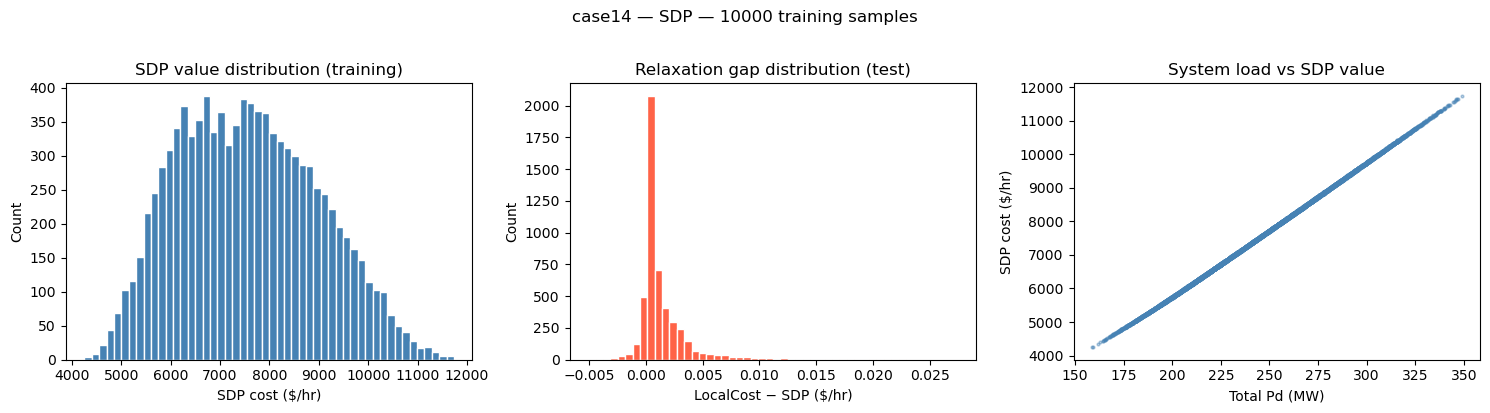

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Distribution of relaxation values
axes[0].hist(df_train["Cost"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel(f"{RELAXATION.upper()} cost ($/hr)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"{RELAXATION.upper()} value distribution (training)")

# 2. Distribution of relaxation gaps in test set
axes[1].hist(relax_gap, bins=50, color="tomato", edgecolor="white")
axes[1].set_xlabel(f"LocalCost − {RELAXATION.upper()} ($/hr)")
axes[1].set_ylabel("Count")
axes[1].set_title("Relaxation gap distribution (test)")

# 3. Total Pd (system load) vs relaxation value
pd_cols = [c for c in feat_cols if c.startswith("Pd")]
total_pd = df_train[pd_cols].sum(axis=1)
axes[2].scatter(total_pd, df_train["Cost"], s=4, alpha=0.4, c="steelblue")
axes[2].set_xlabel("Total Pd (MW)")
axes[2].set_ylabel(f"{RELAXATION.upper()} cost ($/hr)")
axes[2].set_title(f"System load vs {RELAXATION.upper()} value")

plt.suptitle(f"{CASE_NAME} — {RELAXATION.upper()} — {N_TRAIN} training samples", y=1.02)
plt.tight_layout()
plt.show()

## Stage 3 — Train DNN with K-fold cross-validation

Input: demand vector $[P_d^0, \ldots, P_d^{K-1}, Q_d^0, \ldots, Q_d^{K-1}]$ (MW/MVar).  
Output: relaxation lower bound on total generation cost ($/hr).

In [25]:
X_all = df_train[feat_cols].values.astype(np.float32)
y_all = df_train["Cost"].values.astype(np.float32)

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_all)):
    print(f"\n{'='*60}")
    print(f"Fold {fold + 1} / {N_FOLDS}")
    print(f"{'='*60}")

    X_tr, X_val = X_all[train_idx], X_all[val_idx]
    y_tr, y_val = y_all[train_idx], y_all[val_idx]

    model = DNN(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS)

    model, train_losses, val_losses = train_model_two_phase(
        model, X_tr, X_val, y_tr, y_val,
        pretrain_epochs=PRETRAIN_EPOCHS,
        pretrain_lr=PRETRAIN_LR,
        pretrain_batch_size=PRETRAIN_BATCH_SIZE,
        finetune_epochs=FINETUNE_EPOCHS,
        finetune_lr=FINETUNE_LR,
        finetune_batch_size=FINETUNE_BATCH_SIZE,
        weight_decay=WEIGHT_DECAY,
        verbose=True,
    )

    fold_results.append({
        "fold":           fold,
        "model":          model,
        "train_losses":   train_losses,
        "val_losses":     val_losses,
        "phase_boundary": PRETRAIN_EPOCHS,
        "val_idx":        val_idx,
    })


Fold 1 / 2


Fine-tuning: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:09<00:00, 21.61it/s]



Fold 2 / 2


Fine-tuning: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:10<00:00, 19.86it/s]


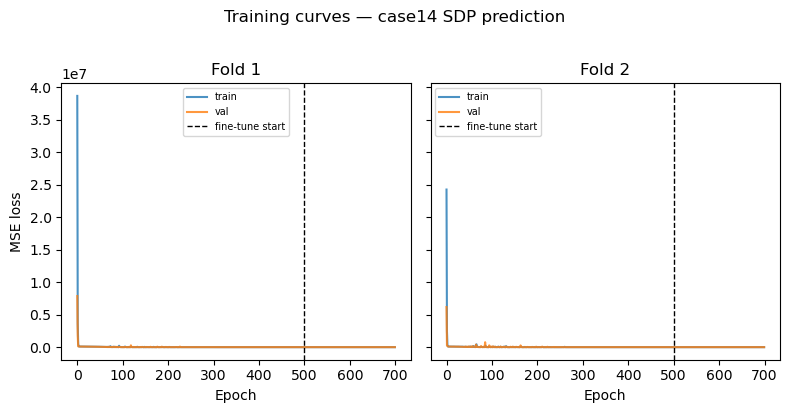

In [27]:
fig, axes = plt.subplots(1, N_FOLDS, figsize=(4 * N_FOLDS, 4), sharey=True)
if N_FOLDS == 1:
    axes = [axes]
for fold, res in enumerate(fold_results):
    ax = axes[fold]
    ax.plot(res["train_losses"], label="train", alpha=0.8)
    ax.plot(res["val_losses"],   label="val",   alpha=0.8)
    ax.axvline(res["phase_boundary"], color="k", lw=1, ls="--", label="fine-tune start")
    ax.set_title(f"Fold {fold + 1}")
    ax.set_xlabel("Epoch")
    if fold == 0:
        ax.set_ylabel("MSE loss")
    ax.legend(fontsize=7)
plt.suptitle(f"Training curves — {CASE_NAME} {RELAXATION.upper()} prediction", y=1.02)
plt.tight_layout()
plt.show()

## Stage 4 — Evaluate on held-out test set

In [28]:
X_test  = df_test[feat_cols].values.astype(np.float32)
y_relax = df_test["Cost"].values.astype(np.float32)
y_loc   = df_test["LocalCost"].values.astype(np.float32)

# Ensemble average across folds
preds_per_fold = np.stack(
    [predict(res["model"], X_test) for res in fold_results], axis=0
)
y_pred = preds_per_fold.mean(axis=0)

print(f"Error summary — DNN vs {RELAXATION.upper()} (true label):")
print(error_summary(y_relax, y_pred))

gap = y_loc - y_relax
print(f"\nRelaxation gap ({RELAXATION.upper()} vs IPOPT):")
print(f"  mean={gap.mean():.2f}  median={np.median(gap):.2f}  "
      f"p95={np.percentile(gap, 95):.2f}  max={gap.max():.2f} $/hr")

Error summary — DNN vs SDP (true label):
{'n': 5000, 'mean_abs_error': np.float32(1.9508497), 'ci_lower': np.float64(1.8412765209949677), 'ci_upper': np.float64(2.0604227835857207), 'max_abs_error': np.float32(75.69092)}

Relaxation gap (SDP vs IPOPT):
  mean=0.00  median=0.00  p95=0.01  max=0.03 $/hr


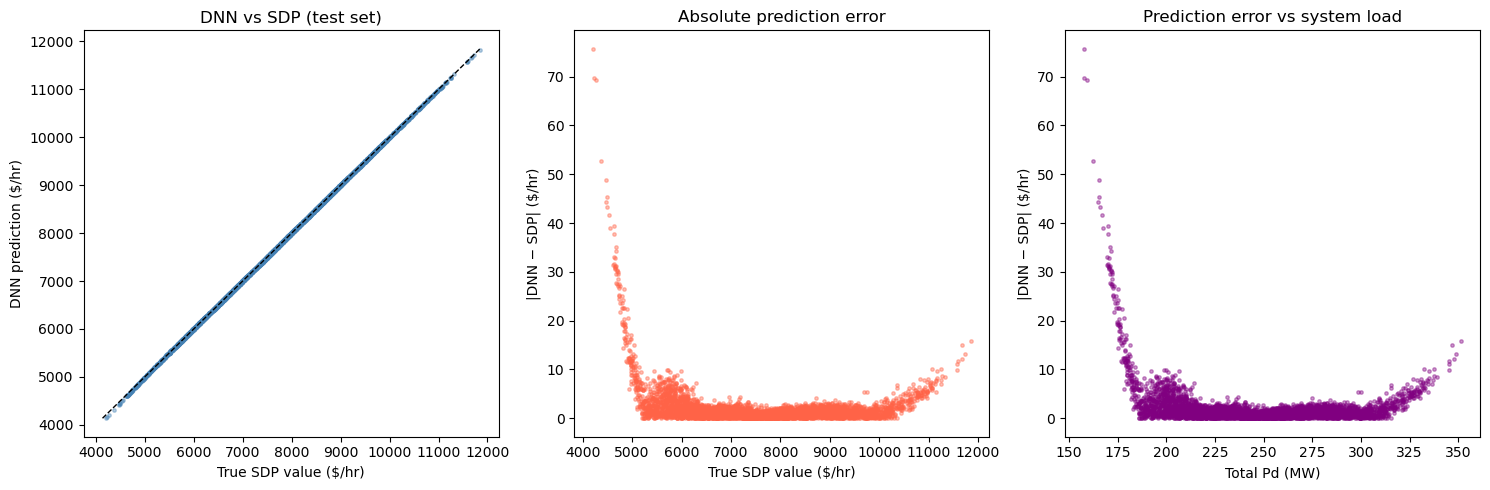

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vmin = min(y_relax.min(), y_pred.min())
vmax = max(y_relax.max(), y_pred.max())

# 1. Predicted vs true relaxation value
axes[0].scatter(y_relax, y_pred, s=6, alpha=0.4, c="steelblue")
axes[0].plot([vmin, vmax], [vmin, vmax], "k--", lw=1)
axes[0].set_xlabel(f"True {RELAXATION.upper()} value ($/hr)")
axes[0].set_ylabel("DNN prediction ($/hr)")
axes[0].set_title(f"DNN vs {RELAXATION.upper()} (test set)")

# 2. Absolute prediction error
abs_err = np.abs(y_pred - y_relax)
axes[1].scatter(y_relax, abs_err, s=6, alpha=0.4, c="tomato")
axes[1].set_xlabel(f"True {RELAXATION.upper()} value ($/hr)")
axes[1].set_ylabel(f"|DNN − {RELAXATION.upper()}| ($/hr)")
axes[1].set_title("Absolute prediction error")

# 3. Total Pd vs absolute error
total_pd_test = df_test[pd_cols].sum(axis=1)
axes[2].scatter(total_pd_test, abs_err, s=6, alpha=0.4, c="purple")
axes[2].set_xlabel("Total Pd (MW)")
axes[2].set_ylabel(f"|DNN − {RELAXATION.upper()}| ($/hr)")
axes[2].set_title("Prediction error vs system load")


plt.tight_layout()
plt.show()

## Stage 5 — Optimality certification confusion matrix

A local IPOPT solution is **actually certifiably optimal** if `LocalCost − Relaxation ≤ TOL`.
The DNN **predicts optimal** if `LocalCost − Pred ≤ TOL`.

**Choosing TOL for SOCP vs SDP:**
- For `sdp` (typically exact on case14): a tight `TOL` (e.g. 1–5 $/hr) works well — the gap is near-zero when the relaxation is exact, so tight certification is meaningful.
- For `socp` (may have a non-trivial gap): a larger `TOL` is needed to certify any solutions at all. However, if the objective landscape has local minima within `TOL` of the global minimum, a false positive becomes possible even if the DNN prediction is accurate — the framework loses discriminating power. Vary `TOL` below to see this trade-off.

In [30]:
df_test["Pred"] = y_pred

# Default TOL: ~2× the median relaxation gap, rounded to a round number.
# Adjust based on the gap statistics printed in Stage 2.
TOL = 50   # $/hr — loosen for SOCP, tighten for SDP

cm = optimality_confusion_matrix(
    df_test["Cost"], df_test["LocalCost"], df_test["Pred"], tol=TOL
)

print(f"Optimality certification — {RELAXATION.upper()} on {CASE_NAME}  (TOL={TOL:.1f} $/hr), n={cm['n']}")
print(f"{'':>20} {'Predicted Optimal':>18} {'Predicted Suboptimal':>22}")
print(f"{'Actually Optimal':>20} {cm['tp']:>18} {cm['fn']:>22}")
print(f"{'Actually Suboptimal':>20} {cm['fp']:>18} {cm['tn']:>22}")
print()
print(f"False positive rate: {cm['fpr']:.4f}")
print(f"False negative rate: {cm['fnr']:.4f}")
print()
n_certifiable = cm['tp'] + cm['fn']
print(f"Certifiable by relaxation (gap ≤ TOL): {n_certifiable} / {cm['n']} "
      f"({100*n_certifiable/cm['n']:.1f}%)")

Optimality certification — SDP on case14  (TOL=50.0 $/hr), n=5000
                      Predicted Optimal   Predicted Suboptimal
    Actually Optimal               4996                      4
 Actually Suboptimal                  0                      0

False positive rate: nan
False negative rate: 0.0008

Certifiable by relaxation (gap ≤ TOL): 5000 / 5000 (100.0%)


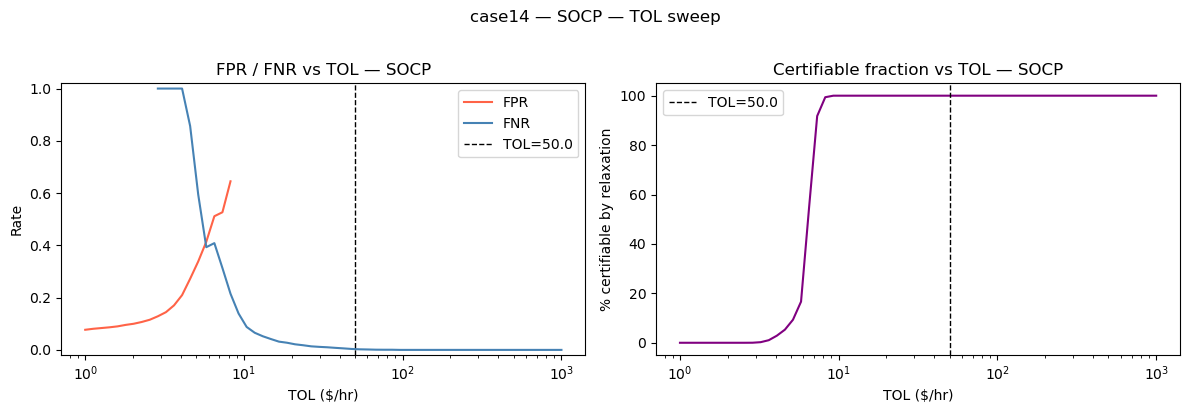

In [14]:
# Sweep TOL to visualise the precision/recall trade-off
tols = np.logspace(0, 3, 60)   # 1 to 1000 $/hr
fprs, fnrs, certifiable_pcts = [], [], []

for tol in tols:
    c = optimality_confusion_matrix(
        df_test["Cost"], df_test["LocalCost"], df_test["Pred"], tol=tol
    )
    fprs.append(c["fpr"])
    fnrs.append(c["fnr"])
    certifiable_pcts.append(100 * (c["tp"] + c["fn"]) / c["n"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogx(tols, fprs, label="FPR", c="tomato")
axes[0].semilogx(tols, fnrs, label="FNR", c="steelblue")
axes[0].axvline(TOL, color="k", lw=1, ls="--", label=f"TOL={TOL}")
axes[0].set_xlabel("TOL ($/hr)")
axes[0].set_ylabel("Rate")
axes[0].set_title(f"FPR / FNR vs TOL — {RELAXATION.upper()}")
axes[0].legend()
axes[0].set_ylim(-0.02, 1.02)

axes[1].semilogx(tols, certifiable_pcts, c="purple")
axes[1].axvline(TOL, color="k", lw=1, ls="--", label=f"TOL={TOL}")
axes[1].set_xlabel("TOL ($/hr)")
axes[1].set_ylabel("% certifiable by relaxation")
axes[1].set_title(f"Certifiable fraction vs TOL — {RELAXATION.upper()}")
axes[1].legend()

plt.suptitle(f"{CASE_NAME} — {RELAXATION.upper()} — TOL sweep", y=1.02)
plt.tight_layout()
plt.show()